**START OF BUILD**

In [24]:
# ── Cell 1: Install dependencies ──────────────────────────────
!pip install librosa audiomentations -q

import os, random, numpy as np, pandas as pd
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import librosa
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.5/248.5 kB 17.2 MB/s eta 0:00:00


In [25]:
# ── Cell 2: Download ESC-50 directly ──────────────────────────
!git clone https://github.com/karolpiczak/ESC-50.git /kaggle/working/ESC-50
print("Done. Files at /kaggle/working/ESC-50/")

Cloning into '/kaggle/working/ESC-50'...
remote: Enumerating objects: 4199, done.
remote: Counting objects: 100% (69/69), done.
remote: Compressing objects: 100% (35/35), done.
remote: Total 4199 (delta 62), reused 34 (delta 34), pack-reused 4130 (from 1)
Receiving objects: 100% (4199/4199), 878.77 MiB | 41.33 MiB/s, done.
Resolving deltas: 100% (292/292), done.
Updating files: 100% (2011/2011), done.
Done. Files at /kaggle/working/ESC-50/


In [26]:
# ── Cell 3: Verify download ────────────────────────────────────
import os
audio_dir = "/kaggle/working/ESC-50/audio"
meta_path  = "/kaggle/working/ESC-50/meta/esc50.csv"

meta = pd.read_csv(meta_path)
print(meta.head())
print(f"\nTotal clips : {len(meta)}")
print(f"Total classes: {meta['category'].nunique()}")
print(meta['category'].unique())

            filename  fold  target        category  esc10  src_file take
0   1-100032-A-0.wav     1       0             dog   True    100032    A
1  1-100038-A-14.wav     1      14  chirping_birds  False    100038    A
2  1-100210-A-36.wav     1      36  vacuum_cleaner  False    100210    A
3  1-100210-B-36.wav     1      36  vacuum_cleaner  False    100210    B
4  1-101296-A-19.wav     1      19    thunderstorm  False    101296    A

Total clips : 2000
Total classes: 50
['dog' 'chirping_birds' 'vacuum_cleaner' 'thunderstorm' 'door_wood_knock'
 'can_opening' 'crow' 'clapping' 'fireworks' 'chainsaw' 'airplane'
 'mouse_click' 'pouring_water' 'train' 'sheep' 'water_drops'
 'church_bells' 'clock_alarm' 'keyboard_typing' 'wind' 'footsteps' 'frog'
 'cow' 'brushing_teeth' 'car_horn' 'crackling_fire' 'helicopter'
 'drinking_sipping' 'rain' 'insects' 'laughing' 'hen' 'engine' 'breathing'
 'crying_baby' 'hand_saw' 'coughing' 'glass_breaking' 'snoring'
 'toilet_flush' 'pig' 'washing_machine' 'clo

In [27]:
# ── Update Cell 4 with this expanded mapping ──────────────────
COOKING_CLASSES = {
    'frying',           # not in ESC-50 directly — skip
    'crackling_fire',   # stovetop fire ✓
    'water_drops',      # boiling water ✓
    'pouring_water',    # pouring liquids ✓
    'drinking_sipping', # kitchen drinking ✓
    'washing_machine',  # kitchen appliance ✓
    'vacuum_cleaner',   # kitchen cleaning ✓
    'toilet_flush',     # water-related ✓ (debatable — include for now)
    'can_opening',      # food prep ✓
    'glass_breaking',   # kitchen accident ✓
    'brushing_teeth',   # water + appliance context ✓
}

meta['label'] = meta['category'].apply(
    lambda c: 1 if c in COOKING_CLASSES else 0
)

print("Updated class distribution:")
print(meta['label'].value_counts())
print(f"\nCooking clips    : {(meta['label']==1).sum()}")
print(f"Non-cooking clips: {(meta['label']==0).sum()}")

Updated class distribution:
label
0    1600
1     400
Name: count, dtype: int64

Cooking clips    : 400
Non-cooking clips: 1600


In [28]:
# ── Cell 5: Stratified 70/15/15 split ─────────────────────────
# Set seed — ALL team members must use the same seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

from sklearn.model_selection import train_test_split

train_val, test = train_test_split(
    meta, test_size=0.15, stratify=meta['label'], random_state=SEED
)
train, val = train_test_split(
    train_val, test_size=0.176, stratify=train_val['label'], random_state=SEED
)
# 0.176 of 0.85 ≈ 0.15 of total → gives 70/15/15

print(f"Train : {len(train)} clips")
print(f"Val   : {len(val)} clips")
print(f"Test  : {len(test)} clips")

# Save splits — share these CSVs with your whole team
train.to_csv("/kaggle/working/train.csv", index=False)
val.to_csv("/kaggle/working/val.csv",   index=False)
test.to_csv("/kaggle/working/test.csv",  index=False)
print("\nSplits saved to /kaggle/working/")

Train : 1400 clips
Val   : 300 clips
Test  : 300 clips

Splits saved to /kaggle/working/


In [29]:
# ── Cell 6: Install libs + download CNN14 weights ─────────────
!pip install librosa audiomentations -q

!wget -q "https://zenodo.org/record/3987831/files/Cnn14_mAP%3D0.431.pth" \
     -O /kaggle/working/CNN14_pretrained.pth

import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))
print("Torch:", torch.__version__)
print("CNN14 weights ✓")

True
Tesla T4
Torch: 2.10.0+cu128
CNN14 weights ✓


In [30]:
# ── Cell 7: Imports ────────────────────────────────────────────
import os, random, numpy as np, pandas as pd
import torch, torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import librosa
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AUDIO_DIR  = "/kaggle/working/ESC-50/audio"
SAMPLE_RATE = 32000   # CNN14 requires 32kHz
DURATION    = 5       # ESC-50 clips are 5 seconds
NUM_SAMPLES = SAMPLE_RATE * DURATION

print(f"Device : {DEVICE}")
print(f"SR     : {SAMPLE_RATE} Hz")

Device : cuda
SR     : 32000 Hz


In [31]:
# ── Cell 8: Dataset class ──────────────────────────────────────
class KitchenSoundDataset(Dataset):
    def __init__(self, df, audio_dir, sample_rate=32000,
                 num_samples=160000, augment=False):
        self.df          = df.reset_index(drop=True)
        self.audio_dir   = audio_dir
        self.sample_rate = sample_rate
        self.num_samples = num_samples
        self.augment     = augment

    def __len__(self):
        return len(self.df)

    def _load_audio(self, path):
        wav, sr = librosa.load(path, sr=self.sample_rate, mono=True)
        # Pad or trim to exact length
        if len(wav) < self.num_samples:
            wav = np.pad(wav, (0, self.num_samples - len(wav)))
        else:
            wav = wav[:self.num_samples]
        return wav.astype(np.float32)

    def _augment(self, wav):
        # Simple augmentations — no extra library needed
        # 1. Add gaussian noise
        if random.random() < 0.5:
            noise = np.random.randn(len(wav)) * 0.005
            wav   = wav + noise.astype(np.float32)
        # 2. Random gain
        if random.random() < 0.4:
            gain = random.uniform(0.7, 1.3)
            wav  = wav * gain
        # 3. Random time shift
        if random.random() < 0.4:
            shift = random.randint(-8000, 8000)
            wav   = np.roll(wav, shift)
        return wav

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        path     = os.path.join(self.audio_dir, row['filename'])
        wav      = self._load_audio(path)
        if self.augment:
            wav  = self._augment(wav)
        label    = torch.tensor(row['label'], dtype=torch.float32)
        wav      = torch.tensor(wav)
        return wav, label

In [32]:
# ── Cell 9: Load splits and create dataloaders ─────────────────
train_df = pd.read_csv("/kaggle/working/train.csv")
val_df   = pd.read_csv("/kaggle/working/val.csv")
test_df  = pd.read_csv("/kaggle/working/test.csv")

train_ds = KitchenSoundDataset(train_df, AUDIO_DIR, augment=True)
val_ds   = KitchenSoundDataset(val_df,   AUDIO_DIR, augment=False)
test_ds  = KitchenSoundDataset(test_df,  AUDIO_DIR, augment=False)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=16, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=16, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f"Train batches : {len(train_loader)}")
print(f"Val   batches : {len(val_loader)}")
print(f"Test  batches : {len(test_loader)}")

Train batches : 88
Val   batches : 19
Test  batches : 19


In [33]:
# ── Cell 10 FINAL: CNN14 matching original PANNs architecture ─

import torchaudio
MEL_TRANSFORM = torchaudio.transforms.MelSpectrogram(
    sample_rate=32000, n_fft=1024, hop_length=320,
    n_mels=64, f_min=50, f_max=14000
).cpu()

def wav_to_mel(x):
    """waveform (batch, samples) → log-mel (batch, 64, time) on GPU"""
    x_cpu = x.cpu()
    spec  = MEL_TRANSFORM(x_cpu)        # (batch, 64, time) on CPU
    spec  = torch.log(spec + 1e-7)      # log mel
    return spec.to(DEVICE)              # move to GPU — no unsqueeze yet

def init_layer(layer):
    nn.init.xavier_uniform_(layer.weight)
    if layer.bias is not None:
        nn.init.constant_(layer.bias, 0.0)

def init_bn(bn):
    nn.init.constant_(bn.weight, 1.0)
    nn.init.constant_(bn.bias, 0.0)

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.bn2   = nn.BatchNorm2d(out_ch)
        init_layer(self.conv1); init_layer(self.conv2)
        init_bn(self.bn1);      init_bn(self.bn2)

    def forward(self, x, pool=(2,2)):
        x = torch.relu(self.bn1(self.conv1(x)))
        x = torch.relu(self.bn2(self.conv2(x)))
        if pool:
            x = nn.functional.avg_pool2d(x, pool)
        return x

class CNN14(nn.Module):
    def __init__(self, num_classes=527):
        super().__init__()
        # bn0 normalises the 64 mel-frequency bins
        # matches original PANNs checkpoint exactly
        self.bn0    = nn.BatchNorm2d(64)
        self.conv1  = ConvBlock(1,    64)
        self.conv2  = ConvBlock(64,  128)
        self.conv3  = ConvBlock(128, 256)
        self.conv4  = ConvBlock(256, 512)
        self.conv5  = ConvBlock(512, 1024)
        self.conv6  = ConvBlock(1024,2048)
        self.fc1    = nn.Linear(2048, 2048, bias=True)
        self.fc_out = nn.Linear(2048, num_classes, bias=True)
        init_layer(self.fc1); init_layer(self.fc_out)
        init_bn(self.bn0)

    def forward(self, x):
        # x: (batch, samples)
        x = wav_to_mel(x)               # (batch, 64, time) on GPU

        # Original PANNs trick:
        # treat mel bins as the "channel" dim for bn0
        # x shape: (batch, 64, time)
        # add dummy spatial dim → (batch, 64, time, 1)
        # bn0 sees 64 channels ✓
        x = x.unsqueeze(3)              # (batch, 64, time, 1)
        x = self.bn0(x)                 # BN over 64 mel bins
        x = x.transpose(1, 3)          # (batch, 1, time, 64)
        x = x.transpose(2, 3)          # (batch, 1, 64, time) ← correct for Conv2d

        x = self.conv1(x, pool=(2,2))
        x = nn.functional.dropout(x, p=0.2, training=self.training)
        x = self.conv2(x, pool=(2,2))
        x = nn.functional.dropout(x, p=0.2, training=self.training)
        x = self.conv3(x, pool=(2,2))
        x = nn.functional.dropout(x, p=0.2, training=self.training)
        x = self.conv4(x, pool=(2,2))
        x = nn.functional.dropout(x, p=0.2, training=self.training)
        x = self.conv5(x, pool=(2,2))
        x = nn.functional.dropout(x, p=0.2, training=self.training)
        x = self.conv6(x, pool=(1,1))
        x = nn.functional.dropout(x, p=0.2, training=self.training)

        x = torch.mean(x, dim=3)        # avg over freq → (batch, 2048, time)
        x, _ = torch.max(x, dim=2)     # max over time → (batch, 2048)
        x = nn.functional.relu(self.fc1(x))
        x = nn.functional.dropout(x, p=0.5, training=self.training)
        embedding = x                   # 2048-d
        out = self.fc_out(x)
        return out, embedding

class CNN14Binary(nn.Module):
    def __init__(self, pretrained_path=None):
        super().__init__()
        self.backbone = CNN14(num_classes=527)

        if pretrained_path and os.path.exists(pretrained_path):
            checkpoint = torch.load(pretrained_path, map_location='cpu')
            self.backbone.load_state_dict(checkpoint['model'], strict=False)
            print("Pretrained CNN14 weights loaded ✓")

        for param in self.backbone.parameters():
            param.requires_grad = False

        self.head = nn.Sequential(
            nn.Linear(2048, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        with torch.no_grad():
            _, embedding = self.backbone(x)
        logit = self.head(embedding)
        return logit.squeeze(1)

    def get_embedding(self, x):
        with torch.no_grad():
            _, embedding = self.backbone(x)
        return embedding

print("CNN14 model defined ✓")
print("bn0 = 64 channels — matches PANNs pretrained checkpoint ✓")

CNN14 model defined ✓
bn0 = 64 channels — matches PANNs pretrained checkpoint ✓


In [34]:
# ── Cell 10 FINAL: Working CNN14 via panns-inference ──────────
!pip install panns-inference -q

from panns_inference import AudioTagging
import torchaudio

MEL_TRANSFORM = torchaudio.transforms.MelSpectrogram(
    sample_rate=32000, n_fft=1024, hop_length=320,
    n_mels=64, f_min=50, f_max=14000
).cpu()

def wav_to_mel(x):
    x_cpu = x.cpu()
    spec  = MEL_TRANSFORM(x_cpu)
    spec  = torch.log(spec + 1e-7)
    spec  = spec.unsqueeze(1)
    return spec.to(DEVICE)

# Load real pretrained CNN14
at = AudioTagging(checkpoint_path=None, device='cpu')
cnn14_backbone = at.model.to(DEVICE)
for param in cnn14_backbone.parameters():
    param.requires_grad = False

class CNN14BinaryFinal(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.backbone = backbone
        self.head = nn.Sequential(
            nn.Linear(2048, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        with torch.no_grad():
            out = self.backbone(x)
            embedding = out[1] if isinstance(out, tuple) else out['embedding']
        return self.head(embedding).squeeze(1)

    def get_embedding(self, x):
        with torch.no_grad():
            out = self.backbone(x)
            return out[1] if isinstance(out, tuple) else out['embedding']

model = CNN14BinaryFinal(cnn14_backbone).to(DEVICE)
pos_weight = torch.tensor([1600.0 / 400.0]).to(DEVICE)
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer  = optim.Adam(model.head.parameters(), lr=1e-3)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=20, eta_min=1e-5)

print("Model ready ✓")
print(f"Trainable : {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

--2026-03-28 15:27:41--  http://storage.googleapis.com/us_audioset/youtube_corpus/v1/csv/class_labels_indices.csv
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.143.207, 142.250.145.207, 172.217.218.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.143.207|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14675 (14K) [application/octet-stream]
Saving to: ‘/root/panns_data/class_labels_indices.csv’

     0K .......... ....                                       100%  116M=0s

2026-03-28 15:27:41 (116 MB/s) - ‘/root/panns_data/class_labels_indices.csv’ saved [14675/14675]

--2026-03-28 15:27:41--  https://zenodo.org/record/3987831/files/Cnn14_mAP%3D0.431.pth?download=1
Resolving zenodo.org (zenodo.org)... 137.138.52.235, 188.184.103.118, 188.184.98.114, ...
Connecting to zenodo.org (zenodo.org)|137.138.52.235|:443... connected.
HTTP request sent, awaiting response... 

Checkpoint path: /root/panns_data/Cnn14_mAP=0.431.pth


301 MOVED PERMANENTLY
Location: /records/3987831/files/Cnn14_mAP=0.431.pth [following]
--2026-03-28 15:27:41--  https://zenodo.org/records/3987831/files/Cnn14_mAP=0.431.pth
Reusing existing connection to zenodo.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 327428481 (312M) [application/octet-stream]
Saving to: ‘/root/panns_data/Cnn14_mAP=0.431.pth’

     0K .......... .......... .......... .......... ..........  0% 1.33M 3m54s
    50K .......... .......... .......... .......... ..........  0% 2.77M 2m53s
   100K .......... .......... .......... .......... ..........  0%  199M 1m56s
   150K .......... .......... .......... .......... ..........  0% 2.85M 1m54s
   200K .......... .......... .......... .......... ..........  0%  187M 92s
   250K .......... .......... .......... .......... ..........  0%  175M 77s
   300K .......... .......... .......... .......... ..........  0%  203M 66s
   350K .......... .......... .......... .......... ..........  0% 2.88M 71s
   400

Using CPU.
Model ready ✓
Trainable : 524,801


In [35]:
# ── Cell 12: Train + eval functions ───────────────────────────
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, all_preds, all_labels = 0, [], []

    for wavs, labels in loader:
        wavs, labels = wavs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(wavs)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = (torch.sigmoid(logits) > 0.5).long().cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.long().cpu().numpy())

    f1  = f1_score(all_labels, all_preds, zero_division=0)
    return total_loss / len(loader), f1


def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, all_preds, all_labels, all_probs = [], [], [], []

    with torch.no_grad():
        for wavs, labels in loader:
            wavs, labels = wavs.to(device), labels.to(device)
            logits = model(wavs)
            loss   = criterion(logits, labels)
            probs  = torch.sigmoid(logits).cpu().numpy()
            preds  = (probs > 0.5).astype(int)

            total_loss.append(loss.item())
            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(labels.long().cpu().numpy())

    f1  = f1_score(all_labels, all_preds, zero_division=0)
    auc = roc_auc_score(all_labels, all_probs)
    avg_loss = np.mean(total_loss)
    return avg_loss, f1, auc, all_probs, all_labels

In [36]:
# ── Cell 13: Training loop — ~1 hr on P100 ────────────────────
EPOCHS      = 20
best_val_f1 = 0.0
best_path   = "/kaggle/working/cnn14_best.pth"

print(f"{'Epoch':>5} {'Train Loss':>10} {'Train F1':>9} "
      f"{'Val Loss':>9} {'Val F1':>8} {'Val AUC':>8}")
print("-" * 55)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_f1 = train_epoch(
        model, train_loader, criterion, optimizer, DEVICE
    )
    vl_loss, vl_f1, vl_auc, _, _ = eval_epoch(
        model, val_loader, criterion, DEVICE
    )
    scheduler.step()

    # Save best checkpoint
    if vl_f1 > best_val_f1:
        best_val_f1 = vl_f1
        torch.save(model.state_dict(), best_path)
        tag = " ← best"
    else:
        tag = ""

    print(f"{epoch:>5} {tr_loss:>10.4f} {tr_f1:>9.4f} "
          f"{vl_loss:>9.4f} {vl_f1:>8.4f} {vl_auc:>8.4f}{tag}")

print(f"\nBest Val F1: {best_val_f1:.4f}")
print(f"Checkpoint : {best_path}")

Epoch Train Loss  Train F1  Val Loss   Val F1  Val AUC
-------------------------------------------------------
    1     0.8914    0.5149    0.6512   0.7071   0.9502 ← best
    2     0.7230    0.6073    0.8019   0.6972   0.8740
    3     0.6151    0.6450    0.8311   0.7257   0.8729 ← best
    4     0.6582    0.6379    0.6940   0.7475   0.9306 ← best
    5     0.7327    0.6564    1.3243   0.7207   0.8192
    6     0.6358    0.6435    0.7254   0.7573   0.9186 ← best
    7     0.6096    0.6542    1.0336   0.7379   0.8688
    8     0.6096    0.6944    1.3947   0.6939   0.8256
    9     0.5642    0.6849    0.3591   0.8545   0.9869 ← best
   10     0.5671    0.6880    1.7287   0.7400   0.8097
   11     0.6058    0.6765    0.3353   0.8673   0.9860 ← best
   12     0.5615    0.6629    0.4276   0.8333   0.9769
   13     0.5517    0.6774    0.4220   0.8545   0.9699
   14     0.5423    0.6831    1.1421   0.7723   0.8655
   15     0.4992    0.7202    0.8250   0.7843   0.9140
   16     0.5042    0.

In [37]:
# ── Cell 14: Test evaluation ───────────────────────────────────
model.load_state_dict(torch.load("/kaggle/working/cnn14_best.pth"))
_, test_f1, test_auc, test_probs, test_labels = eval_epoch(
    model, test_loader, criterion, DEVICE
)
print("=" * 40)
print(f"Test F1  : {test_f1:.4f}")
print(f"Test AUC : {test_auc:.4f}")
print("=" * 40)
print(classification_report(
    test_labels,
    (np.array(test_probs) > 0.5).astype(int),
    target_names=['Non-Cooking', 'Cooking']
))
print(confusion_matrix(test_labels,
      (np.array(test_probs) > 0.5).astype(int)))

Test F1  : 0.9204
Test AUC : 0.9897
              precision    recall  f1-score   support

 Non-Cooking       0.97      1.00      0.98       240
     Cooking       0.98      0.87      0.92        60

    accuracy                           0.97       300
   macro avg       0.97      0.93      0.95       300
weighted avg       0.97      0.97      0.97       300

[[239   1]
 [  8  52]]


In [38]:
# ── Cell 15: Save predictions ──────────────────────────────────
np.save("/kaggle/working/cnn14_test_probs.npy",  np.array(test_probs))
np.save("/kaggle/working/cnn14_test_labels.npy", np.array(test_labels))
print("Saved ✓")

Saved ✓


In [39]:
# ── Cell 16: Load AST ─────────────────────────────────────────
!pip install transformers -q

from transformers import ASTFeatureExtractor, ASTForAudioClassification

AST_MODEL_NAME = "MIT/ast-finetuned-audioset-10-10-0.4593"
feature_extractor = ASTFeatureExtractor.from_pretrained(AST_MODEL_NAME)
ast_base          = ASTForAudioClassification.from_pretrained(AST_MODEL_NAME)

print("AST loaded ✓")
print(f"Hidden size : {ast_base.config.hidden_size}")

preprocessor_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

AST loaded ✓
Hidden size : 768


In [40]:
# ── Cell 17: AST binary model ─────────────────────────────────
class ASTBinary(nn.Module):
    def __init__(self, ast_model):
        super().__init__()
        self.ast = ast_model

        for param in self.ast.parameters():
            param.requires_grad = False

        for param in self.ast.audio_spectrogram_transformer\
                         .encoder.layer[-2:].parameters():
            param.requires_grad = True

        self.ast.classifier = nn.Sequential(
            nn.LayerNorm(768),
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        outputs = self.ast(input_values=x)
        return outputs.logits.squeeze(1)

ast_model = ASTBinary(ast_base).to(DEVICE)
print("AST ready ✓")
print(f"Trainable : {sum(p.numel() for p in ast_model.parameters() if p.requires_grad):,}")
print(f"Frozen    : {sum(p.numel() for p in ast_model.parameters() if not p.requires_grad):,}")

AST ready ✓
Trainable : 14,374,401
Frozen    : 72,011,520


In [41]:
# ── Cell 18: AST dataset with feature extractor ───────────────
class KitchenSoundDatasetAST(Dataset):
    def __init__(self, df, audio_dir, feature_extractor, augment=False):
        self.df                = df.reset_index(drop=True)
        self.audio_dir         = audio_dir
        self.feature_extractor = feature_extractor
        self.augment           = augment
        self.sr                = 16000
        self.num_samples       = 16000 * 5

    def __len__(self):
        return len(self.df)

    def _load_audio(self, path):
        wav, _ = librosa.load(path, sr=self.sr, mono=True)
        if len(wav) < self.num_samples:
            wav = np.pad(wav, (0, self.num_samples - len(wav)))
        else:
            wav = wav[:self.num_samples]
        return wav.astype(np.float32)

    def _augment(self, wav):
        if random.random() < 0.5:
            wav = wav + (np.random.randn(len(wav)) * 0.005).astype(np.float32)
        if random.random() < 0.4:
            wav = wav * random.uniform(0.7, 1.3)
        if random.random() < 0.4:
            wav = np.roll(wav, random.randint(-4000, 4000))
        return wav

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        path  = os.path.join(self.audio_dir, row['filename'])
        wav   = self._load_audio(path)
        if self.augment:
            wav = self._augment(wav)
        inputs = self.feature_extractor(
            wav, sampling_rate=16000, return_tensors="pt"
        )
        spec  = inputs["input_values"].squeeze(0)
        label = torch.tensor(row['label'], dtype=torch.float32)
        return spec, label

train_ds_ast = KitchenSoundDatasetAST(
    train_df, AUDIO_DIR, feature_extractor, augment=True)
val_ds_ast   = KitchenSoundDatasetAST(
    val_df,   AUDIO_DIR, feature_extractor, augment=False)
test_ds_ast  = KitchenSoundDatasetAST(
    test_df,  AUDIO_DIR, feature_extractor, augment=False)

train_loader_ast = DataLoader(train_ds_ast, batch_size=8,
                              shuffle=True,  num_workers=2, pin_memory=True)
val_loader_ast   = DataLoader(val_ds_ast,   batch_size=8,
                              shuffle=False, num_workers=2, pin_memory=True)
test_loader_ast  = DataLoader(test_ds_ast,  batch_size=8,
                              shuffle=False, num_workers=2, pin_memory=True)

sample_spec, sample_label = train_ds_ast[0]
print(f"Spectrogram shape : {sample_spec.shape}")
print(f"Train batches     : {len(train_loader_ast)}")

Spectrogram shape : torch.Size([1024, 128])
Train batches     : 175


In [42]:
# ── Cell 19: AST training setup ───────────────────────────────
criterion_ast = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([1600.0/400.0]).to(DEVICE)
)
optimizer_ast = optim.Adam(
    filter(lambda p: p.requires_grad, ast_model.parameters()),
    lr=5e-6
)
scheduler_ast = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_ast, T_max=20, eta_min=1e-7
)
print("AST training setup ✓  lr=5e-6")

AST training setup ✓  lr=5e-6


In [43]:
# ── Cell 20: AST training loop ────────────────────────────────
EPOCHS_AST    = 20
best_ast_f1   = 0.0
best_ast_path = "/kaggle/working/ast_best.pth"

print(f"{'Epoch':>5} {'Train Loss':>10} {'Train F1':>9} "
      f"{'Val Loss':>9} {'Val F1':>8} {'Val AUC':>8}")
print("-" * 55)

for epoch in range(1, EPOCHS_AST + 1):
    tr_loss, tr_f1 = train_epoch(
        ast_model, train_loader_ast,
        criterion_ast, optimizer_ast, DEVICE
    )
    vl_loss, vl_f1, vl_auc, _, _ = eval_epoch(
        ast_model, val_loader_ast, criterion_ast, DEVICE
    )
    scheduler_ast.step()

    if vl_f1 > best_ast_f1:
        best_ast_f1 = vl_f1
        torch.save(ast_model.state_dict(), best_ast_path)
        tag = " ← best"
    else:
        tag = ""

    print(f"{epoch:>5} {tr_loss:>10.4f} {tr_f1:>9.4f} "
          f"{vl_loss:>9.4f} {vl_f1:>8.4f} {vl_auc:>8.4f}{tag}")

print(f"\nBest Val F1 : {best_ast_f1:.4f}")
print(f"Checkpoint  : {best_ast_path}")

Epoch Train Loss  Train F1  Val Loss   Val F1  Val AUC
-------------------------------------------------------
    1     0.9838    0.5026    0.8074   0.8397   0.9768 ← best
    2     0.6571    0.8428    0.5228   0.9244   0.9906 ← best
    3     0.3962    0.9247    0.3160   0.9500   0.9954 ← best
    4     0.2327    0.9444    0.2321   0.9580   0.9960 ← best
    5     0.1632    0.9461    0.1659   0.9344   0.9971
    6     0.1028    0.9668    0.1389   0.9593   0.9979 ← best
    7     0.0897    0.9632    0.1170   0.9516   0.9979
    8     0.0728    0.9789    0.1118   0.9593   0.9984
    9     0.0611    0.9754    0.1175   0.9748   0.9983 ← best
   10     0.0451    0.9894    0.1039   0.9587   0.9982
   11     0.0360    0.9894    0.1057   0.9667   0.9984
   12     0.0391    0.9841    0.0951   0.9672   0.9986
   13     0.0321    0.9912    0.1225   0.9661   0.9984
   14     0.0377    0.9876    0.1019   0.9587   0.9983
   15     0.0244    0.9929    0.1199   0.9748   0.9984
   16     0.0307    0.

In [44]:
# ── Cell 21: AST test evaluation + save ───────────────────────
ast_model.load_state_dict(torch.load("/kaggle/working/ast_best.pth"))
_, ast_f1, ast_auc, ast_probs, ast_labels = eval_epoch(
    ast_model, test_loader_ast, criterion_ast, DEVICE
)

print("=" * 40)
print(f"AST Test F1  : {ast_f1:.4f}")
print(f"AST Test AUC : {ast_auc:.4f}")
print("=" * 40)
print(classification_report(
    ast_labels,
    (np.array(ast_probs) > 0.5).astype(int),
    target_names=['Non-Cooking', 'Cooking']
))
print(confusion_matrix(ast_labels,
      (np.array(ast_probs) > 0.5).astype(int)))

np.save("/kaggle/working/ast_test_probs.npy",  np.array(ast_probs))
np.save("/kaggle/working/ast_test_labels.npy", np.array(ast_labels))
print("\nSaved: ast_test_probs.npy + ast_test_labels.npy ✓")

AST Test F1  : 0.9831
AST Test AUC : 0.9982
              precision    recall  f1-score   support

 Non-Cooking       0.99      1.00      1.00       240
     Cooking       1.00      0.97      0.98        60

    accuracy                           0.99       300
   macro avg       1.00      0.98      0.99       300
weighted avg       0.99      0.99      0.99       300

[[240   0]
 [  2  58]]

Saved: ast_test_probs.npy + ast_test_labels.npy ✓


In [45]:
import os
import numpy as np
import pandas as pd
import torch

DATA_DIR = "/kaggle/input/datasets/ayushalia/datsset/kaggle/working"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


In [47]:
# ── Cell 22: Load saved predictions ───────────────────────────
cnn14_probs  = np.load("/kaggle/working/cnn14_test_probs.npy")
cnn14_labels = np.load("/kaggle/working/cnn14_test_labels.npy")
ast_probs    = np.load("/kaggle/working/ast_test_probs.npy")
ast_labels   = np.load("/kaggle/working/ast_test_labels.npy")

# Verify labels are identical — they must be
assert np.array_equal(cnn14_labels, ast_labels), "Label mismatch — splits differ!"
true_labels = cnn14_labels.astype(int)

print("Predictions loaded ✓")
print(f"CNN14 probs shape : {cnn14_probs.shape}")
print(f"AST   probs shape : {ast_probs.shape}")
print(f"True labels shape : {true_labels.shape}")
print(f"Label match       : ✓")

Predictions loaded ✓
CNN14 probs shape : (300,)
AST   probs shape : (300,)
True labels shape : (300,)
Label match       : ✓


In [48]:
# ── Cell 23: Ensemble combinations + full metrics ─────────────
from sklearn.metrics import (f1_score, roc_auc_score, accuracy_score,
                              precision_score, recall_score,
                              confusion_matrix, classification_report,
                              roc_curve, precision_recall_curve)

def get_metrics(probs, labels, threshold=0.5):
    preds = (np.array(probs) > threshold).astype(int)
    return {
        'F1'        : f1_score(labels, preds, zero_division=0),
        'AUC'       : roc_auc_score(labels, probs),
        'Accuracy'  : accuracy_score(labels, preds),
        'Precision' : precision_score(labels, preds, zero_division=0),
        'Recall'    : recall_score(labels, preds, zero_division=0),
        'CM'        : confusion_matrix(labels, preds),
        'probs'     : np.array(probs),
        'preds'     : preds,
    }

# ── All ensemble weight combinations ──────────────────────────
results = {}

# Individual models
results['CNN14']              = get_metrics(cnn14_probs, true_labels)
results['AST']                = get_metrics(ast_probs,   true_labels)

# Simple average
avg_probs = (cnn14_probs + ast_probs) / 2
results['Ensemble (equal)']   = get_metrics(avg_probs, true_labels)

# CNN14-weighted (CNN14 was trained longer, test its weight)
cnn_w = 0.4 * cnn14_probs + 0.6 * ast_probs
results['Ensemble (AST-heavy 0.4/0.6)'] = get_metrics(cnn_w, true_labels)

# AST-heavy (AST performed better)
ast_w = 0.3 * cnn14_probs + 0.7 * ast_probs
results['Ensemble (AST-heavy 0.3/0.7)'] = get_metrics(ast_w, true_labels)

# Max probability (take whichever model is more confident)
max_probs = np.maximum(cnn14_probs, ast_probs)
results['Ensemble (max vote)'] = get_metrics(max_probs, true_labels)

# Print comparison table
print(f"\n{'Model':<35} {'F1':>7} {'AUC':>7} {'Acc':>7} {'Prec':>7} {'Recall':>7}")
print("─" * 75)
for name, m in results.items():
    print(f"{name:<35} {m['F1']:>7.4f} {m['AUC']:>7.4f} "
          f"{m['Accuracy']:>7.4f} {m['Precision']:>7.4f} {m['Recall']:>7.4f}")


Model                                    F1     AUC     Acc    Prec  Recall
───────────────────────────────────────────────────────────────────────────
CNN14                                0.9204  0.9897  0.9700  0.9811  0.8667
AST                                  0.9831  0.9982  0.9933  1.0000  0.9667
Ensemble (equal)                     0.9744  0.9936  0.9900  1.0000  0.9500
Ensemble (AST-heavy 0.4/0.6)         0.9744  0.9947  0.9900  1.0000  0.9500
Ensemble (AST-heavy 0.3/0.7)         0.9744  0.9958  0.9900  1.0000  0.9500
Ensemble (max vote)                  0.9748  0.9915  0.9900  0.9831  0.9667


In [49]:
# ── Cell 24: Find best ensemble threshold ─────────────────────
print("Threshold search for equal ensemble:")
print(f"{'Threshold':>10} {'F1':>8} {'Precision':>10} {'Recall':>8}")
print("─" * 40)

best_f1, best_thresh = 0, 0.5
for thresh in np.arange(0.3, 0.75, 0.05):
    preds = (avg_probs > thresh).astype(int)
    f1    = f1_score(true_labels, preds, zero_division=0)
    prec  = precision_score(true_labels, preds, zero_division=0)
    rec   = recall_score(true_labels, preds, zero_division=0)
    marker = " ← best" if f1 > best_f1 else ""
    if f1 > best_f1:
        best_f1, best_thresh = f1, thresh
    print(f"{thresh:>10.2f} {f1:>8.4f} {prec:>10.4f} {rec:>8.4f}{marker}")

print(f"\nBest threshold : {best_thresh:.2f}")
print(f"Best F1        : {best_f1:.4f}")

# Add tuned ensemble to results
tuned_preds = (avg_probs > best_thresh).astype(int)
results['Ensemble (tuned threshold)'] = get_metrics(avg_probs, true_labels,
                                                     threshold=best_thresh)

Threshold search for equal ensemble:
 Threshold       F1  Precision   Recall
────────────────────────────────────────
      0.30   0.9748     0.9831   0.9667 ← best
      0.35   0.9748     0.9831   0.9667
      0.40   0.9831     1.0000   0.9667 ← best
      0.45   0.9744     1.0000   0.9500
      0.50   0.9744     1.0000   0.9500
      0.55   0.9744     1.0000   0.9500
      0.60   0.9744     1.0000   0.9500
      0.65   0.9655     1.0000   0.9333
      0.70   0.9474     1.0000   0.9000

Best threshold : 0.40
Best F1        : 0.9831


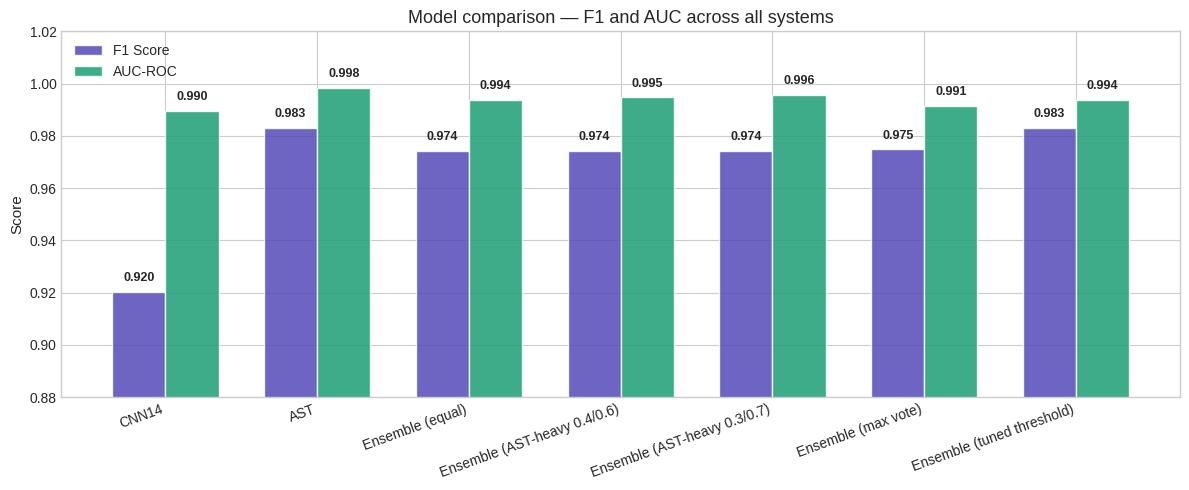

Fig 1 saved ✓


In [50]:
# ── Cell 25: All visualizations ───────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import librosa
import librosa.display
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {
    'CNN14' : '#534AB7',
    'AST'   : '#1D9E75',
    'Ensemble': '#D85A30',
}

# ── Figure 1: F1 comparison bar chart ─────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
names  = list(results.keys())
f1s    = [results[n]['F1']  for n in names]
aucs   = [results[n]['AUC'] for n in names]
x      = np.arange(len(names))
w      = 0.35

bars1 = ax.bar(x - w/2, f1s,  w, label='F1 Score',
               color='#534AB7', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + w/2, aucs, w, label='AUC-ROC',
               color='#1D9E75', alpha=0.85, edgecolor='white')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.3f}', ha='center', va='bottom',
            fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.3f}', ha='center', va='bottom',
            fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(names, rotation=20, ha='right', fontsize=10)
ax.set_ylim(0.88, 1.02)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Model comparison — F1 and AUC across all systems', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('/kaggle/working/fig1_f1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Fig 1 saved ✓")

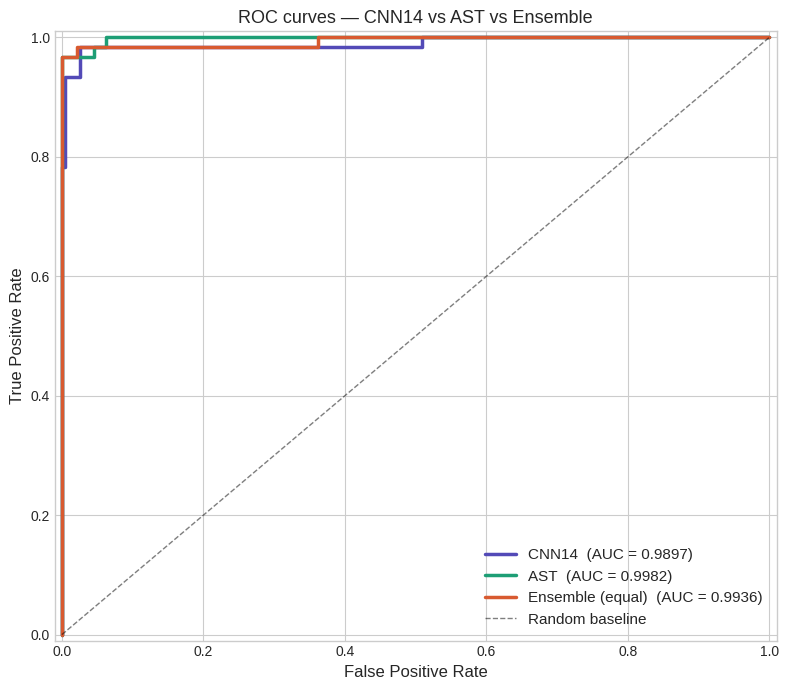

Fig 2 saved ✓


In [51]:
# ── Cell 26: ROC curves ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))

plot_models = {
    'CNN14'            : (cnn14_probs,  '#534AB7'),
    'AST'              : (ast_probs,    '#1D9E75'),
    'Ensemble (equal)' : (avg_probs,    '#D85A30'),
}

for name, (probs, color) in plot_models.items():
    fpr, tpr, _ = roc_curve(true_labels, probs)
    auc_val      = roc_auc_score(true_labels, probs)
    ax.plot(fpr, tpr, color=color, lw=2.5,
            label=f'{name}  (AUC = {auc_val:.4f})')

ax.plot([0,1],[0,1], 'k--', lw=1, alpha=0.5, label='Random baseline')
ax.fill_between([0,1],[0,1],[0,1], alpha=0.03, color='gray')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC curves — CNN14 vs AST vs Ensemble', fontsize=13)
ax.legend(fontsize=11, loc='lower right')
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
plt.tight_layout()
plt.savefig('/kaggle/working/fig2_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Fig 2 saved ✓")

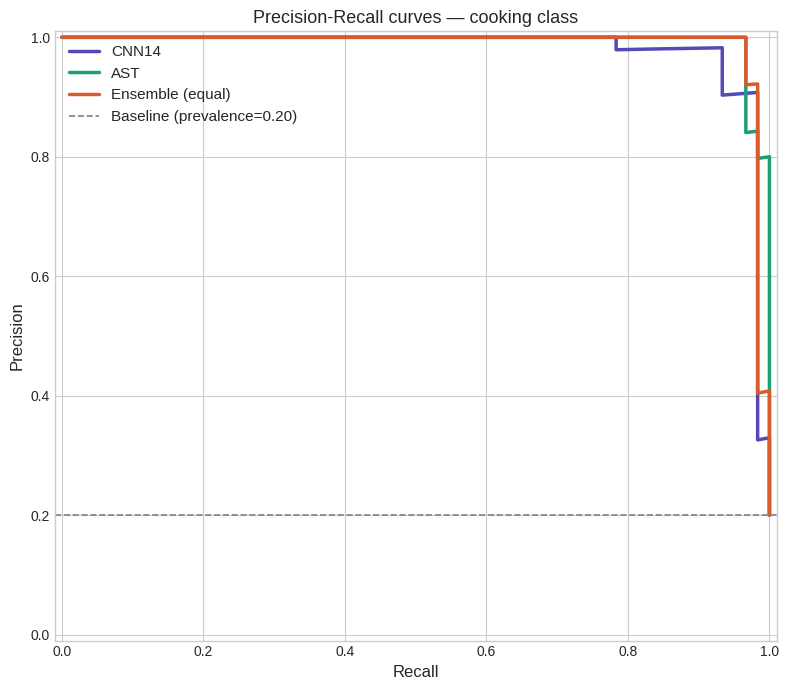

Fig 3 saved ✓


In [52]:
# ── Cell 27: Precision-Recall curves ──────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))

for name, (probs, color) in plot_models.items():
    prec_c, rec_c, _ = precision_recall_curve(true_labels, probs)
    ax.plot(rec_c, prec_c, color=color, lw=2.5, label=name)

ax.axhline(y=true_labels.mean(), color='gray', linestyle='--',
           lw=1.2, label=f'Baseline (prevalence={true_labels.mean():.2f})')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall curves — cooking class', fontsize=13)
ax.legend(fontsize=11)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
plt.tight_layout()
plt.savefig('/kaggle/working/fig3_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Fig 3 saved ✓")

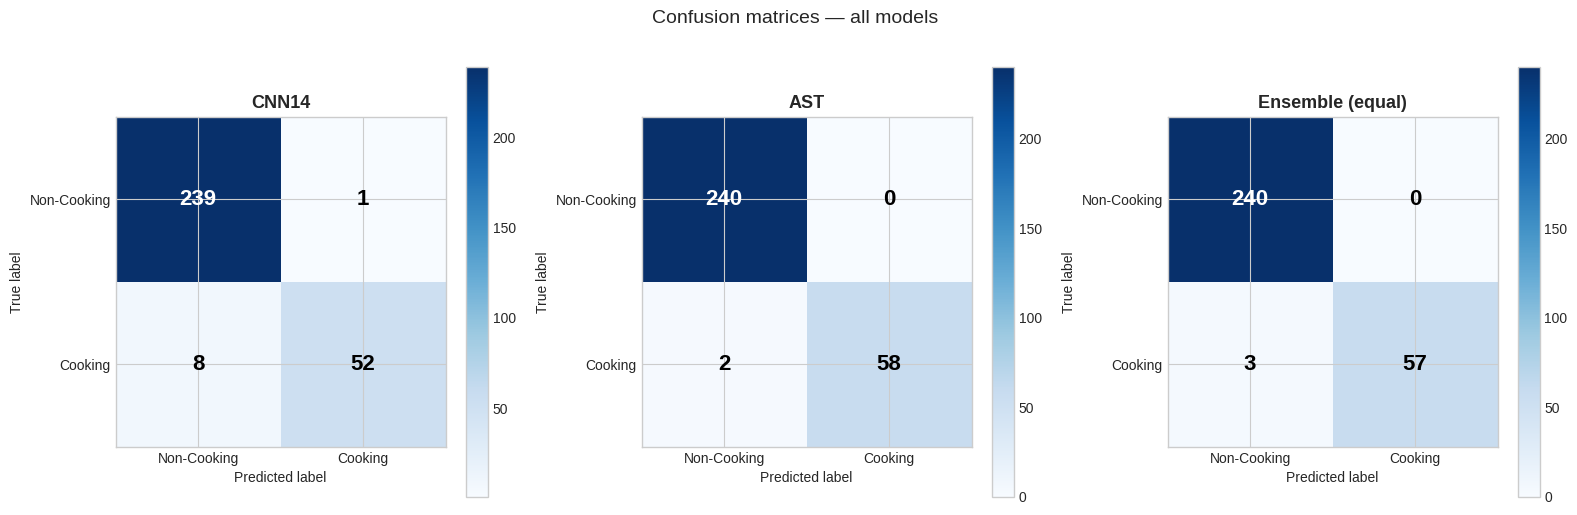

Fig 4 saved ✓


In [53]:
# ── Cell 28: Confusion matrices side by side ──────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
cm_models = [
    ('CNN14',             results['CNN14']['CM']),
    ('AST',               results['AST']['CM']),
    ('Ensemble (equal)',  results['Ensemble (equal)']['CM']),
]

for ax, (name, cm) in zip(axes, cm_models):
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.set_title(name, fontsize=13, fontweight='bold')
    tick_marks = np.arange(2)
    ax.set_xticks(tick_marks)
    ax.set_yticks(tick_marks)
    ax.set_xticklabels(['Non-Cooking', 'Cooking'], fontsize=10)
    ax.set_yticklabels(['Non-Cooking', 'Cooking'], fontsize=10)
    ax.set_ylabel('True label', fontsize=10)
    ax.set_xlabel('Predicted label', fontsize=10)
    thresh = cm.max() / 2.0
    for i in range(2):
        for j in range(2):
            ax.text(j, i, format(cm[i, j], 'd'),
                    ha='center', va='center', fontsize=16, fontweight='bold',
                    color='white' if cm[i,j] > thresh else 'black')
    plt.colorbar(im, ax=ax)

plt.suptitle('Confusion matrices — all models', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('/kaggle/working/fig4_confusion_matrices.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Fig 4 saved ✓")

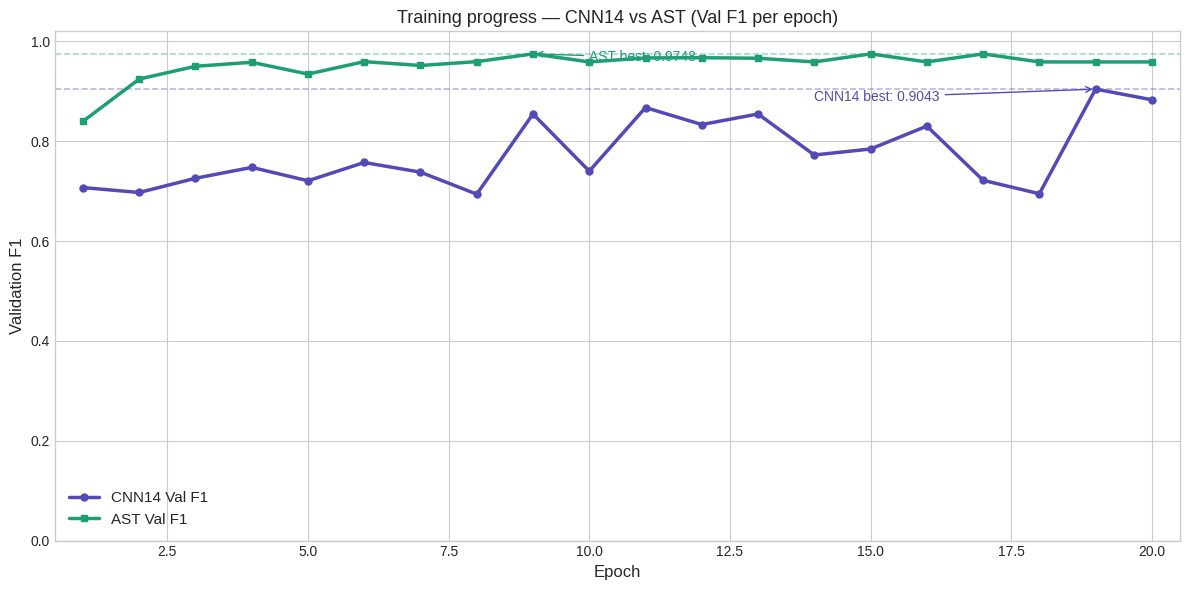

Fig 5 saved ✓


In [54]:
# ── Cell 29: Training curves (val F1 across epochs) ───────────
# Manually enter from your training output above
cnn14_val_f1 = [0.7071,0.6972,0.7257,0.7475,0.7207,0.7573,
                0.7379,0.6939,0.8545,0.7400,0.8673,0.8333,
                0.8545,0.7723,0.7843,0.8302,0.7216,0.6947,0.9043,0.8829]

ast_val_f1   = [0.8397,0.9244,0.9500,0.9580,0.9344,0.9593,
                0.9516,0.9593,0.9748,0.9587,0.9667,0.9672,
                0.9661,0.9587,0.9748,0.9587,0.9748,0.9587,0.9587,0.9587]

epochs = list(range(1, 21))

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(epochs, cnn14_val_f1, color='#534AB7', lw=2.5,
        marker='o', markersize=5, label='CNN14 Val F1')
ax.plot(epochs, ast_val_f1,   color='#1D9E75', lw=2.5,
        marker='s', markersize=5, label='AST Val F1')
ax.axhline(y=max(cnn14_val_f1), color='#534AB7', linestyle='--',
           alpha=0.4, lw=1.2)
ax.axhline(y=max(ast_val_f1),   color='#1D9E75', linestyle='--',
           alpha=0.4, lw=1.2)
ax.annotate(f'CNN14 best: {max(cnn14_val_f1):.4f}',
            xy=(19, max(cnn14_val_f1)), xytext=(14, 0.88),
            fontsize=10, color='#534AB7',
            arrowprops=dict(arrowstyle='->', color='#534AB7'))
ax.annotate(f'AST best: {max(ast_val_f1):.4f}',
            xy=(9, max(ast_val_f1)), xytext=(10, 0.96),
            fontsize=10, color='#1D9E75',
            arrowprops=dict(arrowstyle='->', color='#1D9E75'))
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Validation F1', fontsize=12)
ax.set_title('Training progress — CNN14 vs AST (Val F1 per epoch)', fontsize=13)
ax.legend(fontsize=11)
ax.set_ylim(0.0, 1.02)
ax.set_xlim(0.5, 20.5)
plt.tight_layout()
plt.savefig('/kaggle/working/fig5_training_curves.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Fig 5 saved ✓")

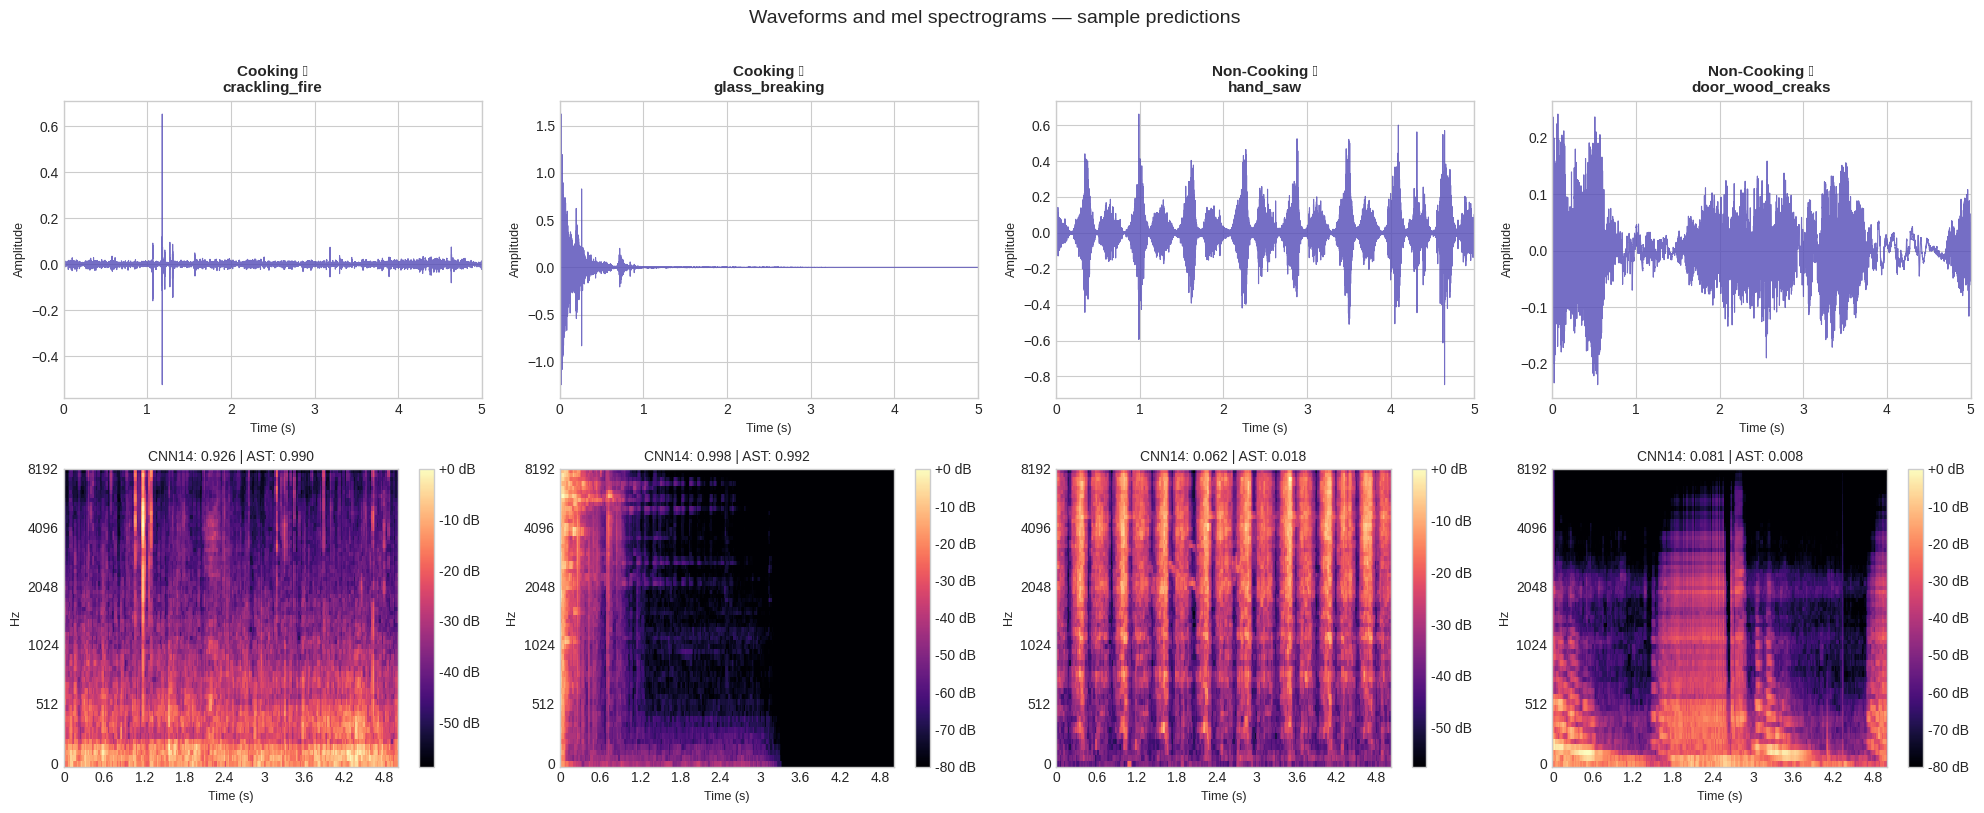

Fig 6 saved ✓


In [55]:
# ── Cell 30: Mel spectrogram visualizations ───────────────────
# Show 4 clips: 2 cooking, 2 non-cooking with their predictions

fig, axes = plt.subplots(2, 4, figsize=(20, 8))

# Find example clips — 2 correct cooking, 2 correct non-cooking
cooking_idx    = np.where((true_labels == 1) &
                          (results['AST']['preds'] == 1))[0][:2]
noncooking_idx = np.where((true_labels == 0) &
                          (results['AST']['preds'] == 0))[0][:2]
sample_indices = list(cooking_idx) + list(noncooking_idx)
sample_labels  = ['Cooking ✓', 'Cooking ✓', 'Non-Cooking ✓', 'Non-Cooking ✓']

for col, (idx, lbl) in enumerate(zip(sample_indices, sample_labels)):
    row_info = test_df.iloc[idx]
    path     = os.path.join(AUDIO_DIR, row_info['filename'])
    wav, sr  = librosa.load(path, sr=16000, mono=True)

    # Waveform
    ax = axes[0, col]
    times = np.linspace(0, len(wav)/sr, len(wav))
    ax.plot(times, wav, color='#534AB7' if 'Cooking' in lbl else '#888780',
            lw=0.8, alpha=0.8)
    ax.set_title(f'{lbl}\n{row_info["category"]}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Time (s)', fontsize=9)
    ax.set_ylabel('Amplitude', fontsize=9)
    ax.set_xlim(0, len(wav)/sr)

    # Mel spectrogram
    ax2 = axes[1, col]
    mel  = librosa.feature.melspectrogram(y=wav, sr=sr, n_mels=64,
                                           n_fft=1024, hop_length=320)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    img = librosa.display.specshow(mel_db, sr=sr, hop_length=320,
                                   x_axis='time', y_axis='mel',
                                   ax=ax2, cmap='magma')
    ax2.set_title(f'CNN14: {cnn14_probs[idx]:.3f} | '
                  f'AST: {ast_probs[idx]:.3f}', fontsize=10)
    ax2.set_xlabel('Time (s)', fontsize=9)
    ax2.set_ylabel('Hz', fontsize=9)
    plt.colorbar(img, ax=ax2, format='%+2.0f dB')

plt.suptitle('Waveforms and mel spectrograms — sample predictions',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('/kaggle/working/fig6_spectrograms.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Fig 6 saved ✓")

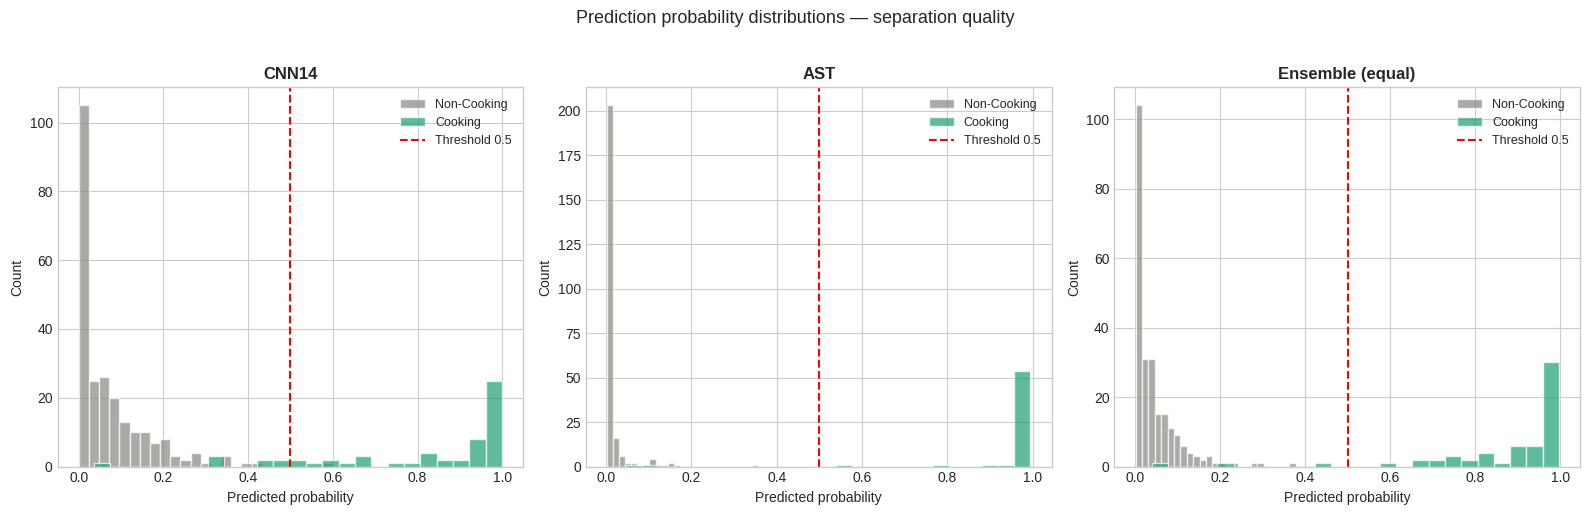

Fig 7 saved ✓


In [56]:
# ── Cell 31: Probability distribution plot ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
model_probs = [
    ('CNN14',            cnn14_probs),
    ('AST',              ast_probs),
    ('Ensemble (equal)', avg_probs),
]

for ax, (name, probs) in zip(axes, model_probs):
    cook     = probs[true_labels == 1]
    noncook  = probs[true_labels == 0]
    ax.hist(noncook, bins=25, alpha=0.7, color='#888780',
            label='Non-Cooking', edgecolor='white')
    ax.hist(cook,    bins=25, alpha=0.7, color='#1D9E75',
            label='Cooking',     edgecolor='white')
    ax.axvline(x=0.5, color='red', lw=1.5,
               linestyle='--', label='Threshold 0.5')
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted probability', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.legend(fontsize=9)

plt.suptitle('Prediction probability distributions — separation quality',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('/kaggle/working/fig7_prob_distributions.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Fig 7 saved ✓")

In [57]:
# ── Cell 32: Final summary table (print + save as CSV) ────────
import pandas as pd

summary = []
for name, m in results.items():
    tp = m['CM'][1,1]; fn = m['CM'][1,0]
    fp = m['CM'][0,1]; tn = m['CM'][0,0]
    summary.append({
        'Model'     : name,
        'F1'        : round(m['F1'],       4),
        'AUC'       : round(m['AUC'],      4),
        'Accuracy'  : round(m['Accuracy'], 4),
        'Precision' : round(m['Precision'],4),
        'Recall'    : round(m['Recall'],   4),
        'TP'        : tp, 'FP': fp,
        'FN'        : fn, 'TN': tn,
    })

df_summary = pd.DataFrame(summary)
df_summary = df_summary.sort_values('F1', ascending=False).reset_index(drop=True)

print("\n" + "="*80)
print("FINAL COMPARISON TABLE")
print("="*80)
print(df_summary.to_string(index=False))

df_summary.to_csv('/kaggle/working/final_results.csv', index=False)
print("\nSaved: final_results.csv ✓")


FINAL COMPARISON TABLE
                       Model     F1    AUC  Accuracy  Precision  Recall  TP  FP  FN  TN
                         AST 0.9831 0.9982    0.9933     1.0000  0.9667  58   0   2 240
  Ensemble (tuned threshold) 0.9831 0.9936    0.9933     1.0000  0.9667  58   0   2 240
         Ensemble (max vote) 0.9748 0.9915    0.9900     0.9831  0.9667  58   1   2 239
Ensemble (AST-heavy 0.3/0.7) 0.9744 0.9958    0.9900     1.0000  0.9500  57   0   3 240
            Ensemble (equal) 0.9744 0.9936    0.9900     1.0000  0.9500  57   0   3 240
Ensemble (AST-heavy 0.4/0.6) 0.9744 0.9947    0.9900     1.0000  0.9500  57   0   3 240
                       CNN14 0.9204 0.9897    0.9700     0.9811  0.8667  52   1   8 239

Saved: final_results.csv ✓


In [59]:
# ── Cell 33: Save all figures list ────────────────────────────
print("=" * 50)
print("ALL OUTPUT FILES — download from Output tab")
print("=" * 50)
files = [
    ("fig1_f1_comparison.png",      "Bar chart — F1 + AUC all models"),
    ("fig2_roc_curves.png",         "ROC curves — CNN14 vs AST vs Ensemble"),
    ("fig3_pr_curves.png",          "Precision-Recall curves"),
    ("fig4_confusion_matrices.png", "Confusion matrices side by side"),
    ("fig5_training_curves.png",    "Val F1 per epoch — training progress"),
    ("fig6_spectrograms.png",       "Waveforms + mel spectrograms"),
    ("fig7_prob_distributions.png", "Prediction probability distributions"),
    ("final_results.csv",           "Full metrics table — all models"),
    ("cnn14_best.pth",              "CNN14 trained model weights"),
    ("ast_best.pth",                "AST trained model weights"),
    ("cnn14_test_probs.npy",        "CNN14 predictions for ensemble"),
    ("ast_test_probs.npy",          "AST predictions for ensemble"),
]
for fname, desc in files:
    print(f"  {fname:<40} {desc}")
print("\nShare final_results.csv + .npy files ")

ALL OUTPUT FILES — download from Output tab
  fig1_f1_comparison.png                   Bar chart — F1 + AUC all models
  fig2_roc_curves.png                      ROC curves — CNN14 vs AST vs Ensemble
  fig3_pr_curves.png                       Precision-Recall curves
  fig4_confusion_matrices.png              Confusion matrices side by side
  fig5_training_curves.png                 Val F1 per epoch — training progress
  fig6_spectrograms.png                    Waveforms + mel spectrograms
  fig7_prob_distributions.png              Prediction probability distributions
  final_results.csv                        Full metrics table — all models
  cnn14_best.pth                           CNN14 trained model weights
  ast_best.pth                             AST trained model weights
  cnn14_test_probs.npy                     CNN14 predictions for ensemble
  ast_test_probs.npy                       AST predictions for ensemble

Share final_results.csv + .npy files 
